# Preparatory–Movement Subspace Orthogonality — Recurrence Only

Quantifies preparatory and movement subspace alignment under the recurrence only condition.

## 1. Imports

Load PCA, plotting, and numerical dependencies.

In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import ipdb


## 2. Interactive Plotting Backend

Activate the widget backend used for figure inspection.

In [2]:
%matplotlib widget


## 3. Data Location and Conditions

Set the data root for all eight conditions.

In [3]:
data_load_path= '..'


## 4. Explained-Variance Helper

Define the component-wise reconstruction metric.

In [5]:
def explained_variance(X, model):
    result = np.zeros(model.n_components)
    for ii in range(model.n_components):
        X_trans = model.transform(X)
        X_trans_ii = np.zeros_like(X_trans)
        X_trans_ii[:, ii] = X_trans[:, ii]
        X_approx_ii = model.inverse_transform(X_trans_ii)

        result[ii] = 1 - (np.linalg.norm(X_approx_ii - X) /
                          np.linalg.norm(X - model.mean_)) ** 2
    return result
    

## 5. Per-Condition Subspace Analysis

Fit three-component preparatory and movement PCAs and compute alignment quantities for each selected condition.

ValueError: num must be an integer with 1 <= num <= 8, not 9

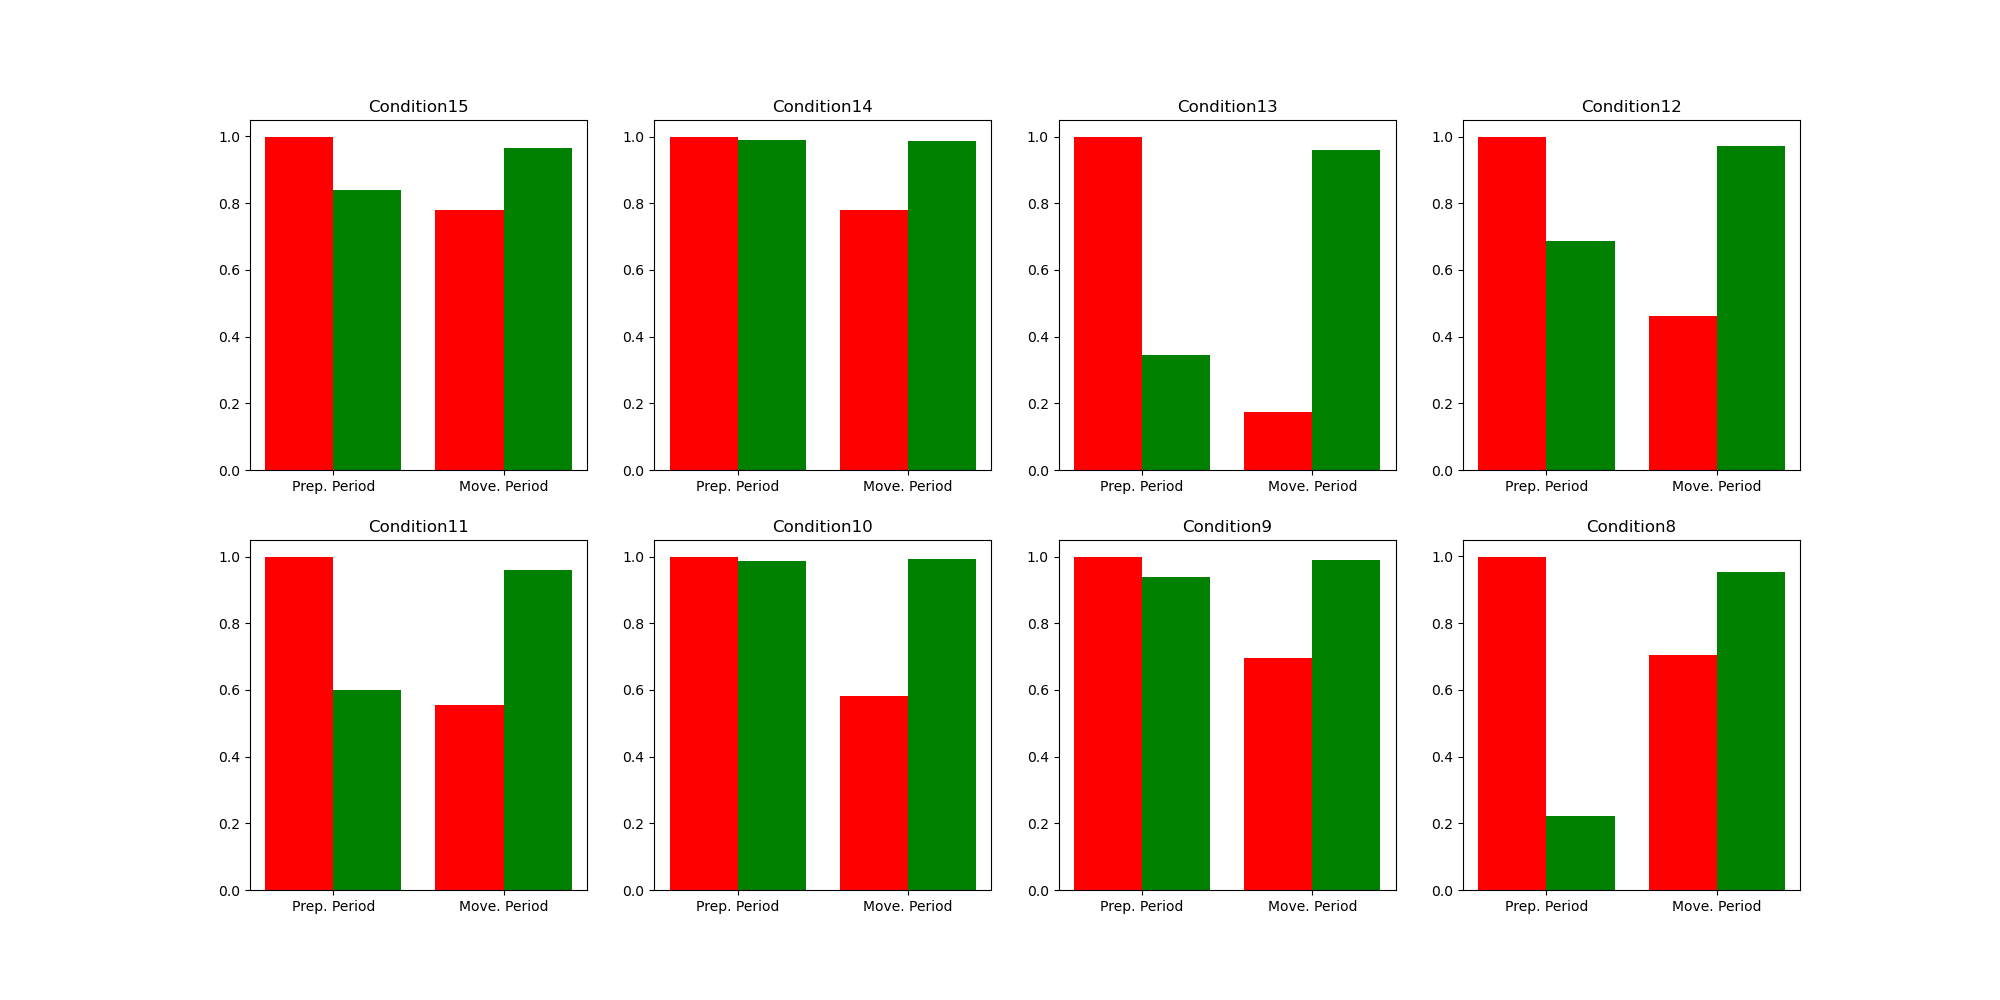

In [6]:
plt.figure(figsize= (20, 10))

prep_var_prep_sub= []
prep_var_move_sub= []
move_var_prep_sub= []
move_var_move_sub= []
alignment_index= []

figcount= 1
for jobid in range(8):

    
    net_act_prep= np.load(data_load_path + f'/fixation_h/net_traj_{jobid+1}.npy')
    net_act_move= np.load(data_load_path + f'/move_h/net_traj_{jobid+1}.npy')
    
    net_traj_prep= net_act_prep[:, :]
    net_traj_move= net_act_move[:, :]
    
    net_traj_prep= net_act_prep
    net_traj_move= net_act_move
    
    
    pca_move= PCA(n_components= 3)
    pca_prep= PCA(n_components= 3)
    
    pca_move.fit(net_traj_move)
    pca_prep.fit(net_traj_prep)
    
    tmove_pmove= pca_move.transform(net_traj_move)
    tmove_pprep= pca_prep.transform(net_traj_move)
    
    tprep_pmove= pca_move.transform(net_traj_prep)
    tprep_pprep= pca_prep.transform(net_traj_prep)

    
    
    
    prep_var_prep_sub_cond= np.sum(explained_variance(net_traj_prep, pca_prep))
    prep_var_move_sub_cond= np.sum(explained_variance(net_traj_prep, pca_move))
    
    move_var_prep_sub_cond= np.sum(explained_variance(net_traj_move, pca_prep))
    move_var_move_sub_cond= np.sum(explained_variance(net_traj_move, pca_move))

    prep_var_prep_sub.append(prep_var_prep_sub_cond)
    prep_var_move_sub.append(prep_var_move_sub_cond)
    move_var_prep_sub.append(move_var_prep_sub_cond)
    move_var_move_sub.append(move_var_move_sub_cond)
    
    alignment_index.append(prep_var_move_sub_cond/prep_var_prep_sub_cond)

    
    plt.subplot(2, 4, figcount)
    figcount +=  1

    periods = ['Prep. Period', 'Move. Period']
    v1, v2 = [np.sum(explained_variance(net_traj_prep, pca_prep)), np.sum(explained_variance(net_traj_move, pca_prep))], [np.sum(explained_variance(net_traj_prep, pca_move)), np.sum(explained_variance(net_traj_move, pca_move))]
    width, x_width = 0.4, np.arange(len(periods))
    
    plt.bar(x_width - width/2, v1, width, label='Prep. Subspace', color= 'red')
    plt.bar(x_width + width/2, v2, width, label='Move. Subspace', color= 'green')
    
    plt.xticks(x_width, periods)
    plt.title(f'Condition{jobid}')
    if jobid == 0:
        plt.ylabel('Values')
        plt.legend()


plt.show()

## 6. Inspect Per-Condition Alignment Values

In [7]:
print(alignment_index)


[np.float64(0.8393811577429723), np.float64(0.9887436629000512), np.float64(0.3458263551236754), np.float64(0.6869479741666324), np.float64(0.5999035643143978), np.float64(0.9868261040441009), np.float64(0.9380635589897095), np.float64(0.22172527197831304), np.float64(0.8040464670899636)]


## 7. Plot Mean Orthogonality

Aggregate the per-condition explained-variance results without changing the underlying calculation.

/tmp/ipykernel_2743405/2769888498.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([x_width[0] - width/2], prep_var_prep_sub[cond], c= colors[cond])
/tmp/ipykernel_2743405/2769888498.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([x_width[0] + width/2], prep_var_move_sub[cond], c= colors[cond])
/tmp/ipykernel_2743405/2769888498.py:17: UserWarning: *c* argument looks like a single numeric RGB

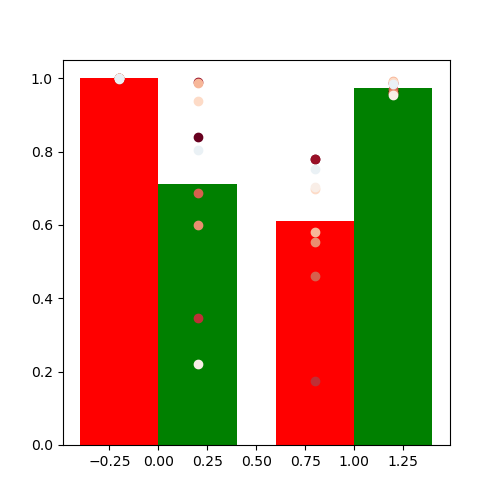

In [8]:
plt.figure(figsize= (5, 5))

n = 8
colors = plt.cm.RdBu(np.linspace(0,1,n))

periods = ['Prep. Period', 'Move. Period']
v1, v2 = [np.mean(prep_var_prep_sub), np.mean(move_var_prep_sub)], [np.mean(prep_var_move_sub), np.mean(move_var_move_sub)]
width, x_width = 0.4, np.arange(len(periods))

plt.bar(x_width - width/2, v1, width, label='Prep. Subspace', color= 'red')
plt.bar(x_width + width/2, v2, width, label='Move. Subspace', color= 'green')

for cond in range(8):
    plt.scatter([x_width[0] - width/2], prep_var_prep_sub[cond], c= colors[cond])
    plt.scatter([x_width[0] + width/2], prep_var_move_sub[cond], c= colors[cond])

    plt.scatter([x_width[1] - width/2], move_var_prep_sub[cond], c= colors[cond])
    plt.scatter([x_width[1] + width/2], move_var_move_sub[cond], c= colors[cond])

plt.xticks(x_width, periods)
plt.title(f'Mean Orthogonality')

plt.ylabel('Values')




plt.show()

print(alignment_index)

## 8. Plot the Mean Alignment Index

0.7123849018166463


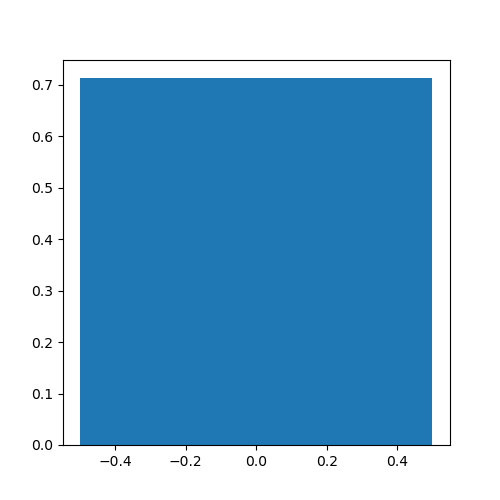

In [9]:

plt.figure(figsize= (5, 5))

plt.bar(0, np.mean(alignment_index), 1, label='Mean Alignment Index')
print(np.mean(alignment_index))

plt.show()

## 9. Pooled-Condition Analysis

Pool trajectories across selected conditions, recompute the subspaces, and save the alignment-index output consumed by the summary notebook.

Alignment Index [0.7742701567585646]


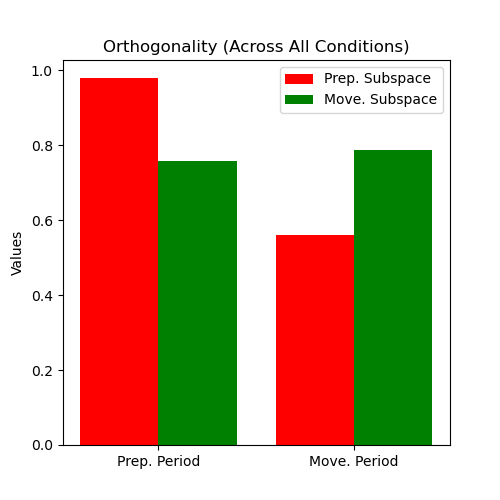

In [10]:

plt.figure(figsize= (5, 5))

prep_var_prep_sub= []
prep_var_move_sub= []
move_var_prep_sub= []
move_var_move_sub= []
alignment_index= []

figcount= 1
net_traj_prep= []
net_traj_move= []
for jobid in range(8):

    
    net_act_prep_c= np.load(data_load_path + f'/fixation_h/net_traj_{jobid+1}.npy')  
    net_act_move_c= np.load(data_load_path + f'/move_h/net_traj_{jobid+1}.npy') 
    
    net_traj_prep_c= net_act_prep_c[:, :]
    net_traj_move_c= net_act_move_c[:, :]

    net_traj_prep.append(net_traj_prep_c)
    net_traj_move.append(net_traj_move_c)

net_traj_prep= np.array(net_traj_prep).reshape((-1, net_traj_prep[0].shape[-1]))
net_traj_move= np.array(net_traj_move).reshape((-1, net_traj_move[0].shape[-1]))

net_traj_prep= net_traj_prep
net_traj_move= net_traj_move


pca_move= PCA(n_components= 3)
pca_prep= PCA(n_components= 3)

pca_move.fit(net_traj_move)
pca_prep.fit(net_traj_prep)




prep_var_prep_sub_cond= np.sum(explained_variance(net_traj_prep, pca_prep))
prep_var_move_sub_cond= np.sum(explained_variance(net_traj_prep, pca_move))

move_var_prep_sub_cond= np.sum(explained_variance(net_traj_move, pca_prep))
move_var_move_sub_cond= np.sum(explained_variance(net_traj_move, pca_move))

prep_var_prep_sub.append(prep_var_prep_sub_cond)
prep_var_move_sub.append(prep_var_move_sub_cond)
move_var_prep_sub.append(move_var_prep_sub_cond)
move_var_move_sub.append(move_var_move_sub_cond)

alignment_index.append(prep_var_move_sub_cond.item()/prep_var_prep_sub_cond.item())
print('Alignment Index', alignment_index)
np.save('./align_index_h.npy', np.array(alignment_index))


periods = ['Prep. Period', 'Move. Period']
v1, v2 = [np.sum(explained_variance(net_traj_prep, pca_prep)), np.sum(explained_variance(net_traj_move, pca_prep))], [np.sum(explained_variance(net_traj_prep, pca_move)), np.sum(explained_variance(net_traj_move, pca_move))]
width, x_width = 0.4, np.arange(len(periods))

plt.bar(x_width - width/2, v1, width, label='Prep. Subspace', color= 'red')
plt.bar(x_width + width/2, v2, width, label='Move. Subspace', color= 'green')

plt.xticks(x_width, periods)
plt.title(f'Orthogonality (Across All Conditions)')
if jobid == 0:
    plt.ylabel('Values')
    plt.legend()



plt.show()
